In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import math
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
#import plotly.express as px
#import plotly.graph_objects as go
import torch
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, ConcatDataset, Subset
from torchvision import transforms
from torchvision.transforms import v2
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torch.nn.functional as F

In [2]:
from transformers import AutoFeatureExtractor, SwinForImageClassification, SwinConfig, AutoModel, AutoImageProcessor, get_scheduler
from transformers import ViTImageProcessor, ViTForImageClassification, EfficientNetModel, EfficientNetForImageClassification,EfficientNetConfig
from transformers import AutoImageProcessor, ResNetForImageClassification
from PIL import Image
import requests
from torch.optim import AdamW
from torch.utils.data import DataLoader, ConcatDataset
from sklearn.model_selection import KFold, StratifiedKFold

2026-03-18 07:06:49.459151: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773817609.640312      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773817609.693440      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773817610.139817      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773817610.139859      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773817610.139862      24 computation_placer.cc:177] computation placer alr

In [3]:
if torch.cuda.is_available():
    print("GPU is available!")
else:
    print("GPU is not available.")

GPU is available!


import torch_xla
import torch_xla.core.xla_model as xm
device = xm.xla_device()
torch.set_default_tensor_type('torch.FloatTensor')

In [4]:
root_dir = "/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset/OriginalDataset"

classes = sorted(os.listdir(root_dir))
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
file_paths = []
labels = []
#for filename in os.listdir(image_folder):
#    if filename.endswith(".jpg") or filename.endswith(".png"):  # Modify based on your image extensions
#        file_paths.append(os.path.join(image_folder, filename))
#        isicid=filename.split(".")[0]
#        labels.append(labels_dict[isicid])
        
for cls in classes:
    cls_path = os.path.join(root_dir, cls)
    for img_name in os.listdir(cls_path):
        file_paths.append(os.path.join(cls_path, img_name))
        labels.append(class_to_idx[cls])

In [5]:
#labels

In [6]:
class_to_idx

{'MildDemented': 0,
 'ModerateDemented': 1,
 'NonDemented': 2,
 'VeryMildDemented': 3}

In [7]:
class MRIdata(Dataset):
    def __init__(self, file_paths, labels, transform=None,device='cpu'):
        self.paths = file_paths
        self.dlabels = labels
        self.transform = transform
        self.device= device

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        x = Image.open(path).convert("RGB")
        x = x.resize((300,300))
        #x = x.resize((224,224))
        x = np.array(x)
        y = self.dlabels[idx]
        y=np.array(y)
        if self.transform:
            x = self.transform(x)
        #x=torch.from_numpy(x).to('cuda')
        #y=torch.from_numpy(y).to('cuda')
        #x = x.to(self.device)
        #y = torch.tensor(y, dtype=torch.long).to(self.device)
        #x = x.to('cuda')
        #y = y.to('cuda')
        #feature_extractor = AutoImageProcessor.from_pretrained("google/efficientnet-b3",do_rescale=False)
        #x=feature_extractor(images=x, return_tensors="pt")
        return x, y

# Define transformations
data_transforms = v2.Compose([
    v2.Resize(300),
    v2.ToImage(),
    #v2.ToDtype(torch.float32, scale=True),
    #v2.RandomHorizontalFlip(p=0.5),
    #v2.RandomVerticalFlip(p=0.5),
    #v2.ColorJitter(brightness=(0.5,1.5), contrast=1.0, saturation=(0.5,1.5), hue=(-0.1,0.1)),
    #v2.RandomRotation(degrees=(0, 180)),
    #v2.RandomAdjustSharpness(sharpness_factor=10, p=0.5),
    v2.ToDtype(torch.float32),
    #v2.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406],
    #                    std=[0.229, 0.224, 0.225])
])

# Create dataset with transformations
dataset = MRIdata(file_paths, labels, transform=data_transforms, device='cuda')

In [8]:
paths = dataset.paths
labels = dataset.dlabels

In [9]:
image, labelsingle = dataset[0]
#image_np = image.numpy().transpose((1, 2, 0))
image_np = np.array(image)

In [10]:
image_np.shape

(3, 300, 300)

In [11]:
#plt.imshow(image_np)

In [12]:
#labels = [dataset[i][1] for i in range(len(dataset))]
labels = [int(l.item()) if isinstance(l, np.ndarray) else int(l) for l in labels]

In [13]:
#labels

In [14]:
#labels

In [15]:
from sklearn.model_selection import train_test_split

# Train (70%) and temp (30%)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths,
    labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

# Split temp into validation (15%) and test (15%)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

In [16]:
from collections import defaultdict
import random

class_dict = defaultdict(list)

# Group training data by class
for path, label in zip(train_paths, train_labels):
    class_dict[label].append((path, label))

# Find smallest class
min_count = min(len(v) for v in class_dict.values())

print("Before Under-sampling:", {k: len(v) for k, v in class_dict.items()})

# Apply under-sampling
balanced_train = []
for label, items in class_dict.items():
    sampled = random.sample(items, min_count)
    balanced_train.extend(sampled)

random.shuffle(balanced_train)

train_paths_bal = [x[0] for x in balanced_train]
train_labels_bal = [x[1] for x in balanced_train]

Before Under-sampling: {3: 1568, 1: 45, 2: 2240, 0: 627}


In [17]:
train_dataset = MRIdata(train_paths_bal, train_labels_bal, transform=data_transforms)
val_dataset   = MRIdata(val_paths, val_labels, transform=data_transforms)
test_dataset  = MRIdata(test_paths, test_labels, transform=data_transforms)

In [18]:
train_loader = DataLoader(train_dataset, shuffle=True)
val_loader   = DataLoader(val_dataset, shuffle=False)
test_loader  = DataLoader(test_dataset, shuffle=False)

from torch.utils.data import Dataset
from PIL import Image

class CustomDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

train_dataset = CustomDataset(train_paths_bal, train_labels_bal, transform)
val_dataset = CustomDataset(val_paths, val_labels, transform)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [19]:
from collections import Counter

print("Train (Under-sampled):", Counter(train_labels_bal))
print("Validation (Original):", Counter(val_labels))
print("Test (Original):", Counter(test_labels))

Train (Under-sampled): Counter({0: 45, 2: 45, 3: 45, 1: 45})
Validation (Original): Counter({2: 480, 3: 336, 0: 134, 1: 10})
Test (Original): Counter({2: 480, 3: 336, 0: 135, 1: 9})


In [20]:
train_labels_bal_clean = [int(l) for l in train_labels_bal]
print("Train distribution:", Counter(train_labels_bal_clean))
val_labels_clean = [int(l.item()) if isinstance(l, np.ndarray) else int(l) for l in val_labels]
print("Validation distribution:", Counter(val_labels_clean))


Train distribution: Counter({0: 45, 2: 45, 3: 45, 1: 45})
Validation distribution: Counter({2: 480, 3: 336, 0: 134, 1: 10})


In [21]:
#feature_ext=AutoImageProcessor.from_pretrained("google/efficientnet-b3",do_rescale=False)
feature_ext = AutoImageProcessor.from_pretrained("microsoft/resnet-50")

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [22]:
image_np
#image_np_rgb = np.stack([image_np]*3, axis=-1) 
fimg = feature_ext(images=image, return_tensors="pt")
#m=EfficientNetModel.from_pretrained("google/efficientnet-b3")
m=ResNetForImageClassification.from_pretrained("microsoft/resnet-50")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [23]:
fimg['pixel_values'].shape

torch.Size([1, 3, 224, 224])

In [24]:
#m(fimg['pixel_values']).pooler_output.shape
m(fimg['pixel_values']).logits.shape

torch.Size([1, 1000])

In [25]:
#m(fimg['pixel_values']).pooler_output.flatten().shape[-1]
m(fimg['pixel_values']).logits.flatten().shape[-1]

1000

In [26]:
#m(fimg['pixel_values']).pooler_output.flatten().to("cuda")
#m(fimg['pixel_values']).logits.flatten().to("cuda")

In [27]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        self.feature_extractor = AutoImageProcessor.from_pretrained("google/efficientnet-b3",do_rescale=False)
        self.model = EfficientNetModel.from_pretrained("google/efficientnet-b3")
        #self.feature_extractor = AutoImageProcessor.from_pretrained("microsoft/resnet-50")
        #self.model = ResNetForImageClassification.from_pretrained("microsoft/resnet-50")
        # Define the custom dense layers
        #self.fc1 = nn.Linear(1000, 512)
        self.fc1 = nn.Linear(1536, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 4)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
        
    def forward(self, x):
        # Extract features using Swin Transformer
        imgs = self.feature_extractor(images=x, return_tensors="pt").to("cuda")
        out = self.model(imgs['pixel_values']).pooler_output.to("cuda")
        #out = self.model(imgs['pixel_values']).logits.to("cuda")
        #pooled_output = features.last_hidden_state.mean(dim=1)
        
        # Pass the features through custom dense layers
        #x = self.fc1(pooled_output)
        x = self.fc1(out)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        
        # Apply sigmoid activation for binary classification
        #x = self.sigmoid(x)
        
        return x

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNNClassifier(nn.Module):

    def __init__(self, num_classes=4):
        super().__init__()

        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.conv3 = nn.Conv2d(64,128,3,padding=1)

        self.pool = nn.MaxPool2d(2,2)

        # adaptive pooling solves size problems
        self.gap = nn.AdaptiveAvgPool2d((1,1))

        self.fc1 = nn.Linear(128,256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,num_classes)

        self.dropout = nn.Dropout(0.5)

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = self.gap(x)            # output (B,128,1,1)
        x = torch.flatten(x,1)     # (B,128)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        x = self.fc3(x)

        return x

In [29]:
model=Classifier()
#model=CNNClassifier()

preprocessor_config.json:   0%|          | 0.00/495 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/49.5M [00:00<?, ?B/s]

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [31]:
model=model.to(device)

In [32]:
class CostSensitiveLossFN(nn.Module):

    def __init__(self, cost_matrix, lambda_fnr=1.0):
        super().__init__()

        self.register_buffer(
            "cost_matrix",
            torch.tensor(cost_matrix, dtype=torch.float32)
        )

        self.lambda_fnr = lambda_fnr


    def forward(self, logits, targets):

        probs = F.softmax(logits, dim=1)

        ce_loss = F.cross_entropy(logits, targets)

        cost_rows = self.cost_matrix[targets]

        cost_penalty = torch.sum(probs * cost_rows, dim=1).mean()

        preds = torch.argmax(probs, dim=1)

        disease_mask = (targets != 2)
        predicted_healthy = (preds == 2)

        fn = (disease_mask & predicted_healthy).float().sum()

        positives = disease_mask.float().sum()

        fnr = fn / (positives + 1e-8)

        loss = ce_loss + cost_penalty + self.lambda_fnr * fnr

        return loss

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class TPRSensitiveLoss(nn.Module):

    def __init__(self, cost_matrix, lambda_tpr=1.0):
        super().__init__()

        # Automatically moves to GPU
        self.register_buffer(
            "cost_matrix",
            torch.tensor(cost_matrix, dtype=torch.float32)
        )

        self.lambda_tpr = lambda_tpr


    def forward(self, logits, targets):

        probs = F.softmax(logits, dim=1)

        ce_loss = F.cross_entropy(logits, targets)

        cost_rows = self.cost_matrix[targets]

        cost_penalty = torch.sum(probs * cost_rows, dim=1).mean()

        preds = torch.argmax(probs, dim=1)

        disease_mask = targets != 2
        predicted_disease = preds != 2

        tp = (disease_mask & predicted_disease).float().sum()

        positives = disease_mask.float().sum()

        tpr = tp / (positives + 1e-8)

        loss = ce_loss + cost_penalty - self.lambda_tpr * tpr

        return loss

In [34]:
#((preds != targets) & (preds > targets)).float().sum()
#(targets != 2)

In [35]:
a=1
cost_matrix = torch.tensor([
[0,     1,    a*2,    1],   # True Mild
[1,     0,    a*3,    2],   # True Moderate
[0.5,   0.33,    0,    1],   # True ND
[1,     0.5,    a*3,    0]    # True VeryMild 
], dtype=torch.float32)

In [36]:
cost_matrix = (cost_matrix - cost_matrix.min()) / (cost_matrix.max() - cost_matrix.min()) #min-max normalization

In [37]:
cost_matrix

tensor([[0.0000, 0.3333, 0.6667, 0.3333],
        [0.3333, 0.0000, 1.0000, 0.6667],
        [0.1667, 0.1100, 0.0000, 0.3333],
        [0.3333, 0.1667, 1.0000, 0.0000]])

In [38]:
batch=16
learning_rate=1e-5

#lossf=nn.BCELoss()
#lossf=nn.CrossEntropyLoss()
lossf= CostSensitiveLossFN(cost_matrix).to(device)
#lossf= TPRSensitiveLoss(cost_matrix).to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)
#optimizer=AdamW(model.parameters(), lr=1e-5)
num_epochs=3

scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer,patience=3)

/tmp/ipykernel_24/2874890184.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(cost_matrix, dtype=torch.float32)


In [39]:
#all_labels

In [40]:
#av

In [41]:
from tqdm import tqdm

In [42]:
for param in model.parameters():
    param.requires_grad = True

In [43]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                print("patience=",self.patience)
                return True
        return False

In [44]:
early_stopper = EarlyStopper(patience=5, min_delta=5)

In [45]:
from torch.cuda.amp import autocast, GradScaler

In [46]:
from sklearn.model_selection import StratifiedKFold

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

In [47]:
#labels

In [48]:
labels_np = np.array(labels)
fold_loaders = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels_np)), labels_np)):
    print(f"\nFold {fold+1}")

    train_subset = Subset(dataset, train_idx)
    val_subset   = Subset(dataset, val_idx)

    train_loader = DataLoader(
        train_subset,
        batch_size=batch,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_subset,
        batch_size=batch,
        shuffle=False,
        num_workers=0
    )

    fold_loaders.append((train_loader, val_loader))


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


In [49]:
#ab

In [50]:
saved_outputs=[]
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []
best_accuracy=0
best_loss=0

for fold, (train_loader, val_loader) in enumerate(fold_loaders):
    print(f"\nTraining Fold {fold+1}/{n_splits}")
    
    for epoch in range(num_epochs):
        train_loss = 0.0
        train_acc = 0.0
        val_loss = 0.0
        val_acc = 0.0
        correct_predictions = 0
        total_predictions = 0
        vcorrect_predictions = 0
        vtotal_predictions = 0
        model.train()
        train_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{num_epochs}")
        for (inputs, labels) in train_bar:
            inputs, labelsgpu = inputs.to(device), labels.to(device)
            #inputs=torch.reshape(inputs, (32, 224,224,3))
            #inputs=inputs.to(torch.float32)
            #input_data = inputs.to(device)
            optimizer.zero_grad()
            #print(inputs)
            #print(inputs.shape)
            #print(inputs.dtype)
            outputs=model(inputs)
            outputscpu=outputs.to('cpu')
            #print(outputs)
            #print(outputs.shape)
            #print(labels)
            #print(labels.shape)
            #labelsgpu=labelsgpu.unsqueeze(1).float()
            loss = lossf(outputs, labelsgpu)
            nplabels=labels.detach()
            nplabels=nplabels.numpy()
            #print(labels.shape)
            #print(labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            #print("outputs:::")
            nptrainout=outputscpu.detach()
            nptrainout=nptrainout.numpy()
            nplabels=nplabels>0
            preds = outputs.argmax(dim=1)
            #print(preds.device)
            #print(labels.device)
            correct_predictions += (preds == labelsgpu.int()).sum().item()
            total_predictions += labels.size(0)
    
            train_bar.set_postfix(
                loss=train_loss / (total_predictions),
                acc=correct_predictions / total_predictions
            )
            
        #before_lr = optimizer.param_groups[0]["lr"]
        #scheduler.step()
        #after_lr = optimizer.param_groups[0]["lr"]
        #print("Epoch %d: SGD lr %.4f -> %.4f" % (epoch, before_lr, after_lr))
            
            
        train_loss /= len(train_loader)
        train_loss_history.append(train_loss)
        #train_acc /= len(train_loader.dataset)
        train_acc =correct_predictions / total_predictions
        train_acc_history.append(train_acc)
        
        # set the model to evaluation mode
        model.eval()
        val_bar = tqdm(val_loader, desc=f"Validation Epoch {epoch+1}/{num_epochs}")
        with torch.no_grad():
            for inputs, labels in val_bar:
                inputs, labelsgpu = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                outputscpu=outputs.to('cpu')
                #labelsgpu=labelsgpu.unsqueeze(1).float()
                #labelcpu=labels.to('cpu')
                nplabels=labels.detach()
                nplabels=nplabels.numpy()
                vloss = lossf(outputs, labelsgpu)
                val_loss += vloss.item()
                #val_acc += (outputs.argmax(1) == labels).sum().item()
                #preds = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
                npvalout=outputscpu.detach()
                nptrainout=npvalout.numpy()
                nplabels=nplabels>0
                #preds = np.where(npvalout > 0, 1, 0)
                preds = outputs.argmax(dim=1)
                #vcorrect_predictions += np.sum(preds == labelsgpu)
                vcorrect_predictions += (preds == labelsgpu).sum().item()
                vtotal_predictions += labels.size(0)
        val_acc =vcorrect_predictions / vtotal_predictions
        if (val_acc > best_accuracy):
            #print(best_accuracy)
            #print(val_acc)
            #print(val_acc > best_accuracy)
            best_accuracy = val_acc
            torch.save(model.state_dict(),'checkpoint_best_val_acc.sav')
            print(f'Saving best model with validation accuracy: {best_accuracy:.4f}')
        scheduler.step(vloss.item())        
        val_loss /= len(val_loader)
        if early_stopper.early_stop(val_loss):
            print("Lower val_Loss of", val_loss)
            break
        val_loss_history.append(val_loss)
        #val_acc /= len(test_loader.dataset)
        val_acc_history.append(val_acc)
        
    
        print(f'Epoch {epoch+1}/{num_epochs}, train loss: {train_loss:.4f}, train acc: {train_acc:.4f}, val loss: {val_loss:.4f}, val acc: {val_acc:.4f}')
        saved_outputs.append((epoch,outputs))


Training Fold 1/5



Validation Epoch 1/3: 100%|██████████| 80/80 [00:23<00:00,  3.39it/s]


Saving best model with validation accuracy: 0.5742
Epoch 1/3, train loss: 1.7876, train acc: 0.4936, val loss: 1.4329, val acc: 0.5742


Validation Epoch 2/3: 100%|██████████| 80/80 [00:17<00:00,  4.63it/s]


Saving best model with validation accuracy: 0.6250
Epoch 2/3, train loss: 1.3363, train acc: 0.6080, val loss: 1.1464, val acc: 0.6250


...

Epoch 1/3, train loss: 0.1070, train acc: 0.9713, val loss: 0.0478, val acc: 0.9836


Validation Epoch 2/3: 100%|██████████| 80/80 [00:17<00:00,  4.65it/s]


Saving best model with validation accuracy: 0.9867
Epoch 2/3, train loss: 0.1035, train acc: 0.9719, val loss: 0.0448, val acc: 0.9867


Validation Epoch 3/3: 100%|██████████| 80/80 [00:17<00:00,  4.61it/s]

Epoch 3/3, train loss: 0.0804, train acc: 0.9779, val loss: 0.0464, val acc: 0.9820


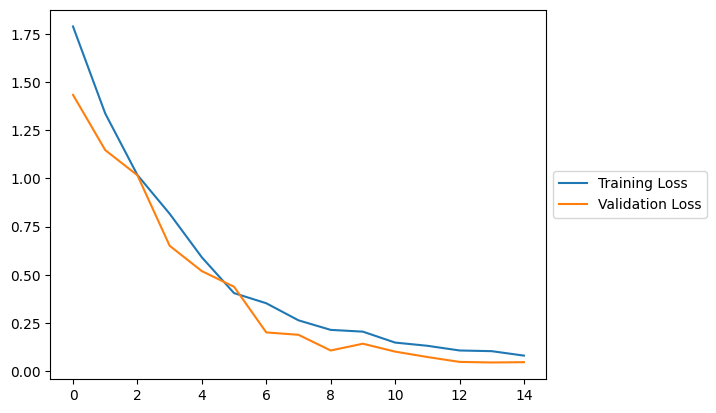

In [51]:
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_loss_history,label='Validation Loss')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

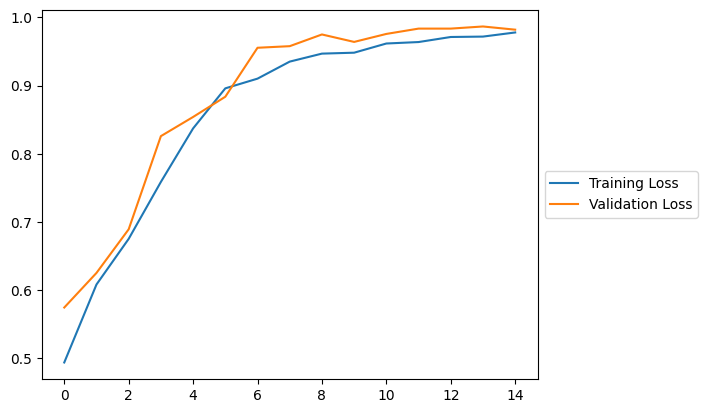

In [52]:
plt.plot(train_acc_history, label='Training Loss')
plt.plot(val_acc_history,label='Validation Loss')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [53]:
import gc
gc.collect()
torch.cuda.empty_cache()

test_idx= torch.load(
    "/kaggle/input/datasets/therealarnab/mri-test/test_idx.pt",
    weights_only=False
)
test_dataset = Subset(dataset, test_idx)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [54]:
#model.load_state_dict(torch.load("/kaggle/input/models/therealarnab/cs70norm/pytorch/default/2/cs70norm5.sav"))

In [55]:
test_probs = []
test_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)                      # logits
        probs = torch.softmax(outputs, dim=1)       # [B, C]

        #for i in labels:
         #   if(i==1):
          #      print(probs.argmax(axis=1))

        test_probs.append(probs.cpu())
        test_labels.append(labels.cpu())

test_probs = torch.cat(test_probs).numpy()
test_labels = torch.cat(test_labels).numpy()

In [56]:
pred_labels= test_probs.argmax(axis=1)

In [57]:
test_probs

array([[5.0729548e-05, 2.9169811e-05, 9.9517536e-01, 4.7447034e-03],
       [1.6769851e-03, 8.9528849e-06, 5.3520926e-04, 9.9777883e-01],
       [9.4875885e-09, 4.3772430e-09, 9.9994898e-01, 5.0958155e-05],
       ...,
       [1.3788868e-08, 6.0620273e-09, 9.9994385e-01, 5.6101118e-05],
       [5.0468893e-06, 1.4183884e-06, 9.9859411e-01, 1.3994580e-03],
       [1.6404345e-08, 4.9803068e-09, 9.9985945e-01, 1.4048642e-04]],
      dtype=float32)

In [58]:
pred_labels

array([2, 3, 2, 3, 3, 3, 3, 2, 3, 2, 2, 2, 0, 2, 2, 0, 3, 0, 2, 2, 3, 2,
       2, 0, 2, 0, 2, 2, 2, 3, 3, 2, 0, 0, 0, 3, 3, 3, 3, 2, 3, 2, 3, 3,
       3, 3, 2, 3, 3, 0, 2, 3, 3, 3, 0, 2, 3, 3, 2, 3, 3, 2, 2, 3, 2, 0,
       2, 3, 2, 2, 3, 2, 2, 0, 2, 2, 3, 2, 2, 2, 2, 3, 3, 3, 2, 3, 0, 3,
       0, 3, 2, 2, 2, 3, 3, 3, 3, 3, 3, 2, 2, 2, 0, 2, 0, 3, 2, 2, 3, 2,
       2, 2, 0, 2, 3, 3, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 3, 2, 2, 2, 3, 2,
       0, 3, 2, 0, 2, 0, 3, 2, 3, 0, 2, 0, 2, 3, 2, 2, 2, 3, 2, 3, 0, 2,
       2, 3, 3, 3, 2, 3, 3, 0, 2, 2, 2, 0, 0, 3, 0, 0, 0, 2, 3, 2, 3, 3,
       2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 0, 2, 3, 3, 3, 3, 0, 3, 3, 0, 2, 3,
       3, 0, 2, 2, 0, 0, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2,
       2, 3, 0, 3, 2, 0, 0, 3, 3, 2, 2, 3, 3, 0, 0, 2, 2, 2, 2, 3, 2, 2,
       3, 3, 3, 2, 2, 3, 0, 3, 2, 3, 3, 2, 0, 3, 0, 3, 2, 3, 3, 3, 2, 3,
       3, 2, 3, 2, 2, 3, 2, 2, 2, 0, 3, 3, 3, 0, 3, 2, 2, 0, 3, 2, 0, 3,
       2, 2, 2, 3, 2, 3, 3, 3, 2, 3, 2, 2, 3, 2, 2,

In [59]:
test_labels

array([2, 3, 2, 3, 3, 3, 3, 2, 3, 2, 2, 2, 0, 2, 2, 0, 3, 3, 2, 2, 3, 2,
       2, 0, 2, 0, 2, 2, 2, 3, 3, 2, 0, 0, 0, 3, 3, 3, 3, 2, 3, 2, 3, 3,
       3, 3, 2, 3, 0, 0, 2, 3, 3, 3, 0, 2, 3, 3, 2, 3, 3, 2, 2, 3, 2, 0,
       2, 3, 2, 2, 3, 2, 2, 0, 2, 2, 3, 2, 2, 2, 2, 3, 3, 3, 2, 3, 0, 3,
       0, 3, 2, 2, 2, 3, 3, 3, 3, 3, 3, 2, 2, 2, 0, 2, 0, 3, 2, 2, 3, 2,
       2, 2, 0, 2, 3, 3, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 3, 2, 2, 2, 3, 2,
       0, 3, 2, 0, 2, 0, 3, 2, 3, 1, 2, 0, 2, 3, 2, 2, 2, 3, 2, 3, 1, 2,
       2, 3, 3, 3, 2, 3, 3, 0, 2, 2, 2, 0, 0, 3, 0, 0, 0, 2, 3, 2, 3, 3,
       2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 0, 2, 3, 3, 3, 3, 0, 3, 3, 0, 2, 3,
       3, 0, 2, 2, 0, 0, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2,
       2, 3, 0, 2, 2, 0, 0, 3, 3, 2, 2, 3, 3, 0, 0, 2, 2, 2, 2, 3, 2, 2,
       3, 3, 3, 2, 2, 3, 0, 3, 2, 3, 3, 2, 0, 3, 0, 3, 2, 3, 3, 3, 2, 3,
       3, 2, 3, 2, 2, 3, 2, 2, 2, 0, 3, 3, 3, 1, 3, 2, 2, 0, 3, 2, 0, 3,
       2, 2, 2, 3, 2, 3, 3, 3, 2, 3, 2, 2, 3, 2, 2,

In [60]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [61]:
classes = [0,1,2,3]

y_test_bin = label_binarize(test_labels, classes=classes)

In [62]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(4):
    
    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        test_probs[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

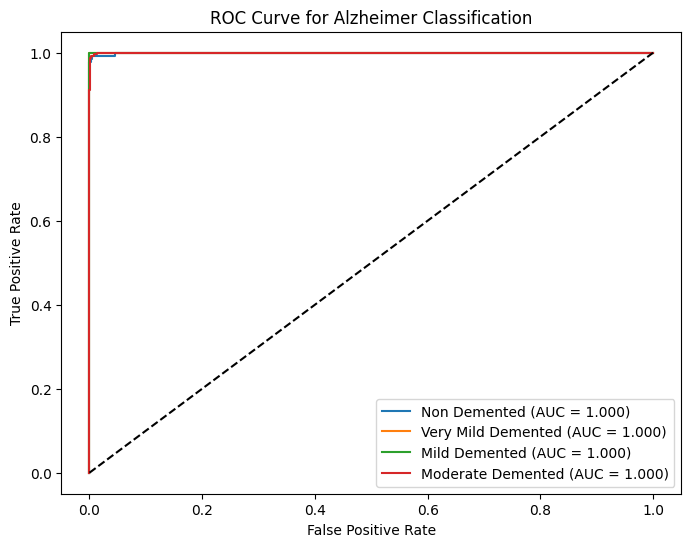

In [63]:
plt.figure(figsize=(8,6))

class_names = [
    "Non Demented",
    "Very Mild Demented",
    "Mild Demented",
    "Moderate Demented"
]

for i in range(4):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Alzheimer Classification")

plt.legend()
plt.show()

In [64]:
from sklearn.metrics import roc_auc_score

macro_auc = roc_auc_score(
    y_test_bin,
    test_probs,
    multi_class='ovr',
    average='macro'
)

print("Macro AUC:", macro_auc)

Macro AUC: 0.9998486295725879


In [65]:
for i,j in enumerate(pred_labels):
    if (j==1):
        print(i,j)

In [66]:
accuracy = np.mean(pred_labels == test_labels)

In [67]:
accuracy

np.float64(0.9833333333333333)

In [68]:
(pred_labels == test_labels).sum() / len(test_labels)

np.float64(0.9833333333333333)

In [69]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, pred_labels)

In [70]:
cm

array([[134,   0,   0,   1],
       [  9,   0,   0,   0],
       [  0,   0, 477,   3],
       [  3,   0,   0, 333]])

In [71]:
from sklearn.metrics import precision_recall_fscore_support as score
precision, recall, fscore, support = score(test_labels, pred_labels)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [72]:
print('precision: {}'.format(precision))
print('recall: {}'.format(recall))
print('fscore: {}'.format(fscore))
print('support: {}'.format(support))

precision: [0.91780822 0.         1.         0.98813056]
recall: [0.99259259 0.         0.99375    0.99107143]
fscore: [0.95373665 0.         0.9968652  0.98959881]
support: [135   9 480 336]


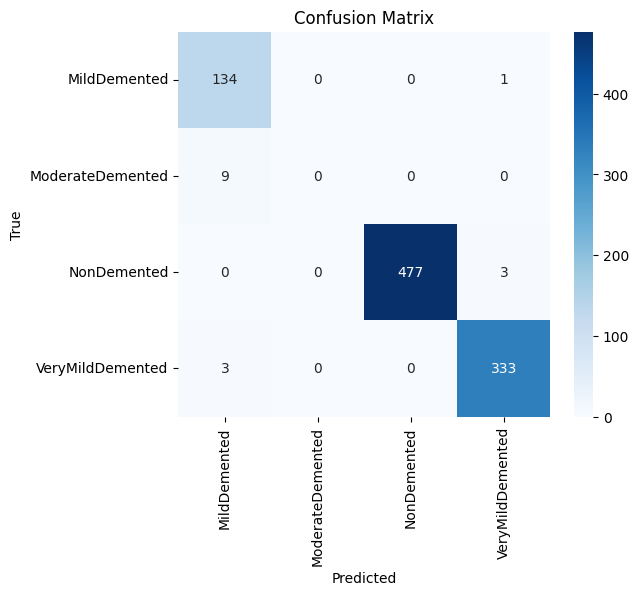

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_to_idx,
    yticklabels=class_to_idx
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [74]:
pred_labels = np.array(pred_labels)
test_labels = np.array(test_labels)

# disease cases (true dementia)
disease_mask = test_labels != 2

# predicted healthy
predicted_healthy = pred_labels == 2

false_negatives = np.sum(disease_mask & predicted_healthy)

print("False Negatives:", false_negatives)

False Negatives: 0


In [75]:
for i in range(len(pred_labels)):
    if pred_labels[i] == 2 and test_labels[i] != 2:
        print(i, pred_labels[i], test_labels[i])

In [76]:
#torch.save(train_idx, "train_idx.pt")
#torch.save(test_idx, "test_idx.pt")
#torch.save(val_idx, "val_idx.pt")